# Product Review Sentiment Analysis — Imbalance-Aware Deep Learning

**Objective:** Classify Amazon product reviews as **Positive**, **Neutral**, or **Negative**
using a deep learning model specifically hardened against severe class imbalance.

---

## Key Challenge: Severe Class Imbalance
The dataset has far more 4-/5-star (Positive) reviews than 1-/2-star (Negative) ones.
Standard models trained naively on this data learn to predict "Positive" almost always,
achieving high accuracy while completely failing on minority classes.

---

## Imbalance-Handling Strategy (4-Layer Defence)

| Layer | Technique | Where Applied |
|-------|-----------|---------------|
| **1** | Stratified train/val/test split | `train_test_split(stratify=y)` |
| **2** | Partial random oversampling (70 % of majority) | Training data preparation |
| **3** | Focal Loss with inverse-frequency alpha weights | Model compilation |
| **4** | Per-class threshold calibration | Post-training inference |

---

## Architecture
- Embedding → SpatialDropout1D → **Stacked BiLSTM** → **Self-Attention** → BatchNorm → Dense → Softmax

## Evaluation Metrics
Standard accuracy · Balanced Accuracy · Macro F1 · Matthews Correlation Coefficient


# ========== IMPORTS ==========

In [115]:
import os, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             balanced_accuracy_score, matthews_corrcoef,
                             f1_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Bidirectional,
                                     Dropout, SpatialDropout1D, GlobalMaxPooling1D,
                                     BatchNormalization, Input, Layer)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


# ========== IMBALANCE-AWARE COMPONENTS ==========
### Focal Loss
Standard cross-entropy treats every sample equally and therefore gets dominated by the majority class.
**Focal Loss** adds a modulating factor `(1 - pt)^γ` that down-weights easy/confident predictions and
forces the model to focus on hard, uncertain examples that typically belong to minority classes.

`FL(p_t) = -α_t · (1 − p_t)^γ · log(p_t)`

- **gamma (γ = 2)** – focusing strength; zero reduces to standard cross-entropy  
- **alpha (α)** – per-class weight inversely proportional to class frequency

### Self-Attention Layer
A trainable attention mechanism that assigns an importance score to each token position.
Instead of pooling all LSTM outputs equally, the model learns *which words matter most*
(e.g., negation words, intensifiers) for predicting Negative and Neutral classes.


In [116]:
# =========================================================
# FOCAL LOSS
# Replaces sparse_categorical_crossentropy to handle class imbalance.
# gamma=2 focuses training on hard/misclassified examples.
# class_alpha provides per-class inverse-frequency weighting (set later
# after oversampling so frequencies are final).
# =========================================================
def focal_loss(gamma=2.0, class_alpha=None):
    """
    Multi-class Focal Loss.
    Args:
        gamma       : focusing parameter (0 = standard CE)
        class_alpha : 1-D list/array of per-class weights [neg, neu, pos]
    """
    def loss_fn(y_true, y_pred):
        y_true_int = tf.cast(
            tf.reshape(y_true, [-1]), tf.int32
        )
        y_true_onehot = tf.one_hot(y_true_int, depth=3)      # (N, 3)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross-entropy component
        ce = -tf.reduce_sum(y_true_onehot * tf.math.log(y_pred), axis=-1)
        # Probability of the true class
        pt = tf.reduce_sum(y_true_onehot * y_pred, axis=-1)
        # Focal weighting
        focal_weight = tf.pow(1.0 - pt, gamma)

        if class_alpha is not None:
            alpha_t_tensor = tf.constant(class_alpha, dtype=tf.float32)
            alpha_t = tf.reduce_sum(y_true_onehot * alpha_t_tensor, axis=-1)
            return tf.reduce_mean(alpha_t * focal_weight * ce)
        return tf.reduce_mean(focal_weight * ce)
    return loss_fn


# =========================================================
# CUSTOM SELF-ATTENTION LAYER
# Learns per-token importance scores to emphasise discriminative
# tokens (negations, sentiment words) over neutral filler text.
# =========================================================
class SelfAttention(Layer):
    """Additive (Bahdanau-style) self-attention over LSTM output sequences."""

    def build(self, input_shape):
        feat_dim = input_shape[-1]
        self.W = self.add_weight(name='attn_W',
                                 shape=(feat_dim, feat_dim),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(name='attn_b',
                                 shape=(feat_dim,),
                                 initializer='zeros',
                                 trainable=True)
        self.u = self.add_weight(name='attn_u',
                                 shape=(feat_dim, 1),
                                 initializer='glorot_uniform',
                                 trainable=True)
        super().build(input_shape)

    def call(self, x):
        # x: (batch, timesteps, features)
        v = tf.tanh(tf.matmul(x, self.W) + self.b)   # (batch, T, F)
        scores = tf.matmul(v, self.u)                  # (batch, T, 1)
        alpha = tf.nn.softmax(scores, axis=1)          # (batch, T, 1)
        context = tf.reduce_sum(x * alpha, axis=1)     # (batch, F)
        return context

    def get_config(self):
        return super().get_config()

print('Focal Loss function and SelfAttention layer defined.')


Focal Loss function and SelfAttention layer defined.


In [117]:
df = pd.read_csv('../datasets/amazon.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: (5515, 12)

Columns: ['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime', 'day_diff', 'helpful_yes', 'helpful_no', 'total_vote', 'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound']


,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4,No issues.,23-07-2014,138,0,0,0,0,0.0,0.0
1,1,0mie,5,"Purchased this for my device, it worked as adv...",25-10-2013,409,0,0,0,0,0.0,0.0
2,2,1K3,4,it works as expected. I should have sprung for...,23-12-2012,715,0,0,0,0,0.0,0.0
3,3,1m2,5,This think has worked out great.Had a diff. br...,21-11-2013,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5,"Bought it with Retail Packaging, arrived legit...",13-07-2013,513,0,0,0,0,0.0,0.0


In [118]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nTotal duplicate rows: {df.duplicated().sum()}')
print(f'\nRating distribution:\n{df["overall"].value_counts().sort_index()}')



Missing values:
Unnamed: 0              0
reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

Total duplicate rows: 0

Rating distribution:
overall
1     444
2     180
3     442
4     527
5    3922
Name: count, dtype: int64


#  EDA Chart 1: Rating Distribution


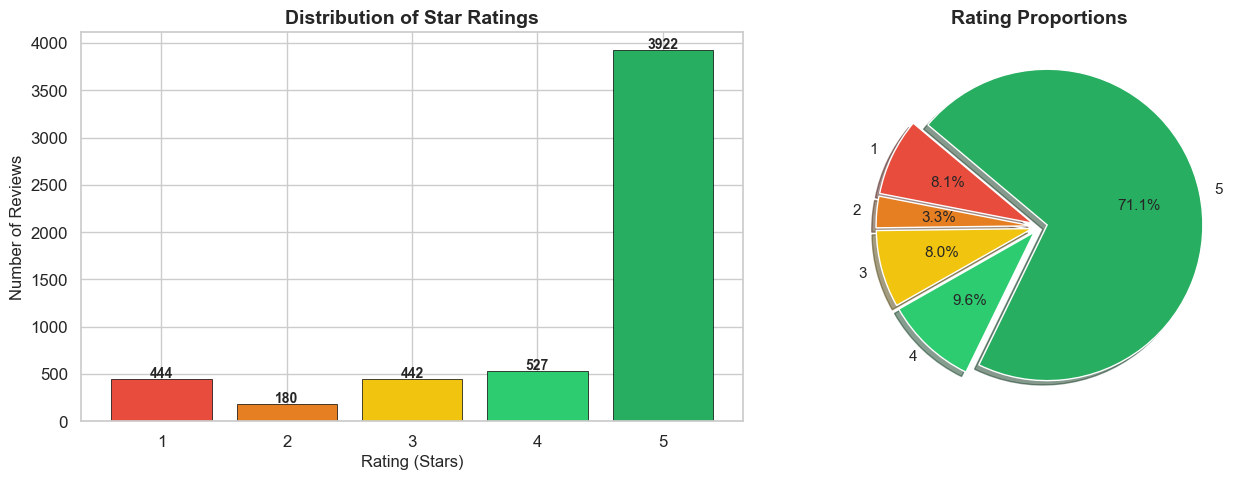

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
rating_counts = df['overall'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Rating (Stars)', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].set_title('Distribution of Star Ratings', fontsize=14, fontweight='bold')
for i, (idx, val) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(idx, val + 20, str(val), ha='center', fontweight='bold', fontsize=10)

# Pie chart
axes[1].pie(rating_counts.values, labels=[f'{i}' for i in rating_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140,
            explode=[0.05]*len(rating_counts), shadow=True, textprops={'fontsize': 11})
axes[1].set_title('Rating Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/eda_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [120]:
df = df.dropna(subset=['reviewText', 'overall'])
def get_sentiment(rating):
    if rating > 3:
        return 2 # Positive
    elif rating == 3:
        return 1 # Neutral
    else:
        return 0 # Negative

df['sentiment'] = df['overall'].apply(get_sentiment)
df['sentiment_label'] = df['sentiment'].map({0: 'Negative', 1: 'Neutral', 2: 'Positive'})

print(f'After filtering: {len(df)} reviews')
print(f'\nSentiment distribution:\n{df["sentiment_label"].value_counts()}')
print(f'\nImbalance ratio (Pos vs Neg): {sum(df["sentiment"] == 2) / max(1, sum(df["sentiment"] == 0)):.1f}x more positive')



After filtering: 5514 reviews

Sentiment distribution:
sentiment_label
Positive    4448
Negative     624
Neutral      442
Name: count, dtype: int64

Imbalance ratio (Pos vs Neg): 7.1x more positive


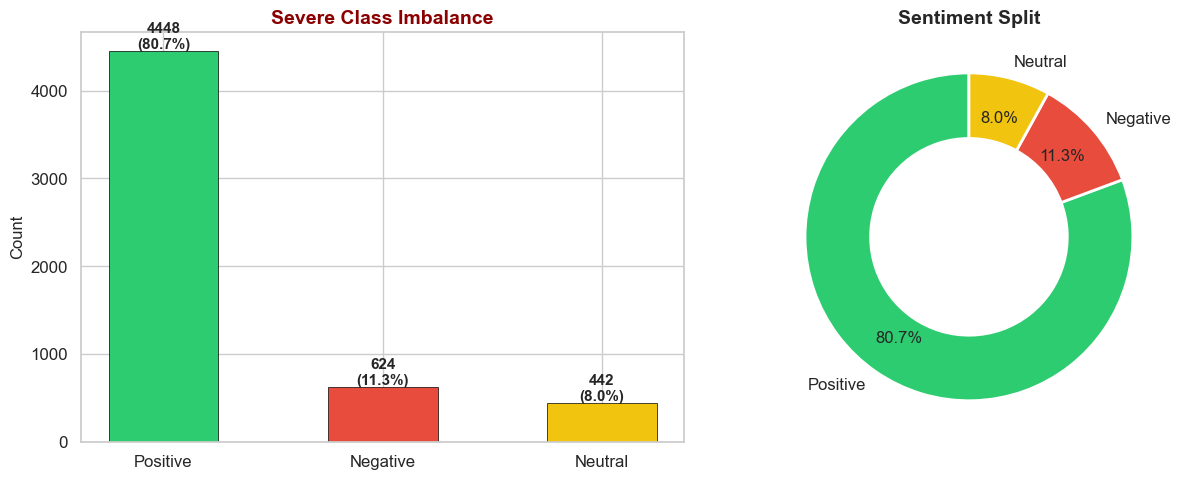

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sent_counts = df['sentiment_label'].value_counts()
bar_colors = ['#2ecc71', '#e74c3c', '#f1c40f'] # Positive, Negative, Neutral respectively based on value_counts order

# Bar chart
bars = axes[0].bar(sent_counts.index, sent_counts.values, color=bar_colors,
                   edgecolor='black', linewidth=0.5, width=0.5)
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Severe Class Imbalance', fontsize=14, fontweight='bold', color='darkred')

# Donut chart
wedges, texts, autotexts = axes[1].pie(sent_counts.values, labels=sent_counts.index,
    autopct='%1.1f%%', colors=bar_colors, startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), textprops={'fontsize':12})
axes[1].set_title('Sentiment Split', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()



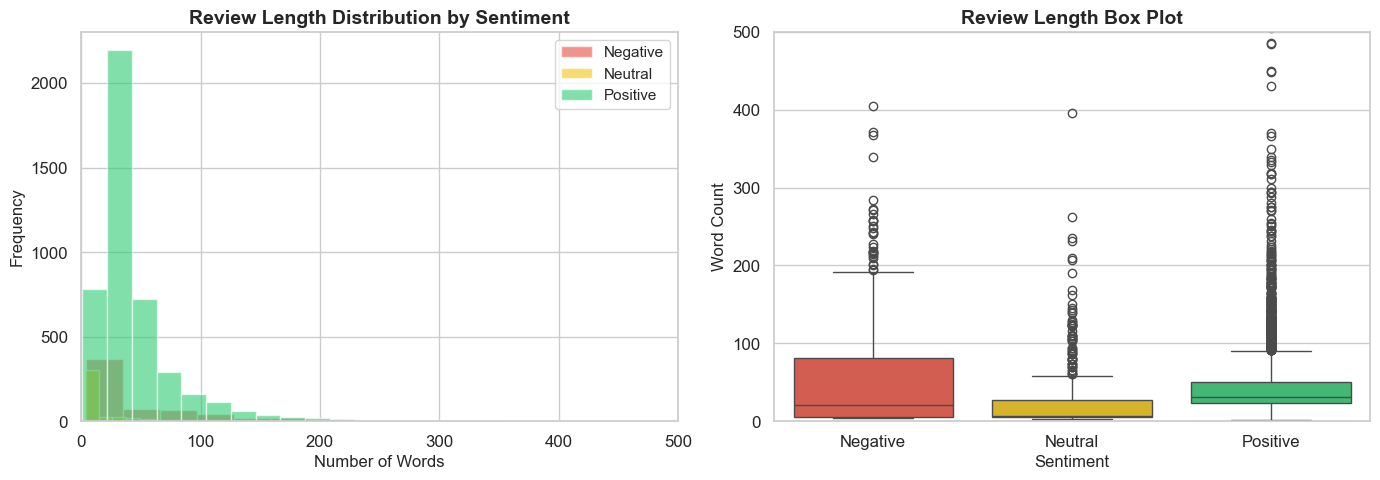

Average review length:
                      mean   50%     max
sentiment_label                         
Negative         58.043269  21.0  1554.0
Neutral          27.583710   7.0   580.0
Positive         45.643660  31.0  1037.0


In [122]:
df['review_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by sentiment
for label, color in zip(['Negative', 'Neutral', 'Positive'], ['#e74c3c', '#f1c40f', '#2ecc71']):
    subset = df[df['sentiment_label'] == label]['review_length']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_xlabel('Number of Words', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Review Length Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xlim(0, 500)

# Box plot
sns.boxplot(data=df, x='sentiment_label', y='review_length', palette=['#e74c3c', '#f1c40f', '#2ecc71'], order=['Negative', 'Neutral', 'Positive'], ax=axes[1])
axes[1].set_ylim(0, 500)
axes[1].set_title('Review Length Box Plot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Word Count', fontsize=12)

plt.tight_layout()
plt.savefig('../models/eda_review_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average review length:')
print(df.groupby('sentiment_label')['review_length'].describe()[['mean', '50%', 'max']])


#  Text Preprocessing

In [123]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
# Keep negation words crucial for sentiment!
negation_words = {'not', 'no', 'nor', 'neither', 'never', 'none', 'nobody',
                  'nothing', 'nowhere', 'hardly', 'barely', 'scarcely',
                  "don't", "doesn't", "didn't", "won't", "wouldn't",
                  "can't", "couldn't", "shouldn't", "isn't", "aren't",
                  "wasn't", "weren't", "hasn't", "haven't", "hadn't","horrible","awful", "terrible", "worst", "disappointing", "poor"}
stop_words = stop_words - negation_words

# Pre-compile regex patterns for performance
html_pattern = re.compile(r'<[^>]+>')
url_pattern = re.compile(r'http\S+|www\S+')
non_alpha_pattern = re.compile(r'[^a-z\s]')
stop_words_pattern = re.compile(r'\b(' + r'|'.join(stop_words) + r')\b\s*')

def clean_text(text):
    text = str(text).lower()
    text = html_pattern.sub('', text)            # Remove HTML tags
    text = url_pattern.sub('', text)             # Remove URLs
    text = non_alpha_pattern.sub('', text)       # Keep only letters
    text = stop_words_pattern.sub('', text)      # Remove stopwords
    # Remove single characters (except a, i) and extra spaces
    text = re.sub(r'\b(?!a\b|i\b)[a-z]\b', '', text)
    return ' '.join(text.split())

df['clean_text'] = df['reviewText'].apply(clean_text)
print('Sample cleaned reviews:')
for i in range(3):
    print(f'  [{df.iloc[i]["sentiment_label"]}] {df.iloc[i]["clean_text"][:100]}...')



# ---
# Train-Test Split & Tokenization

Sample cleaned reviews:
  [Positive] no issues...
  [Positive] purchased device worked advertised never much phone memory since download lot stuff no brainer...
  [Positive] works expected sprung higher capacity think made bit cheesier earlier versions paint looks not clean...


In [124]:
X = df['clean_text'].values
y = df['sentiment'].values

# Stratify BOTH splits so every partition mirrors the original class ratios.
# Without stratify on the training split, the already-rare Negative class
# can be even more under-represented in training by chance.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Validation + test each hold 15% of total data, both stratified
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Train class distribution : {Counter(y_train)}')
print(f'Val   class distribution : {Counter(y_val)}')
print(f'Test  class distribution : {Counter(y_test)}')


Train: 3859 | Val: 827 | Test: 828
Train class distribution : Counter({np.int64(2): 3113, np.int64(0): 437, np.int64(1): 309})
Val   class distribution : Counter({np.int64(2): 667, np.int64(0): 93, np.int64(1): 67})
Test  class distribution : Counter({np.int64(2): 668, np.int64(0): 94, np.int64(1): 66})


In [125]:

VOCAB_SIZE = 30000
MAX_LEN = 150
EMBEDDING_DIM = 128

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>",
    lower=True,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)

tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_val_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_val),
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(f'Effective vocabulary size: {VOCAB_SIZE}')
print(f'Train shape: {X_train_seq.shape}')
print(f'Val shape:   {X_val_seq.shape}')
print(f'Test shape:  {X_test_seq.shape}')
print(f'Dtype check: {X_train_seq.dtype}')

# We use two strategies to combat the severe imbalance:
# 1. Random oversampling of the minority class (negative reviews) to balance the training data
# 2. Class weights as a secondary safeguard during training


Effective vocabulary size: 30000
Train shape: (3859, 150)
Val shape:   (827, 150)
Test shape:  (828, 150)
Dtype check: int32


---

Oversampling target ratio   : 70% of majority (3113)
Minority target size / class: 2179
After oversampling → Positive: 3113 | Neutral: 2179 | Negative: 2179
Total training samples      : 7471

Focal loss alpha weights (Neg, Neu, Pos): [0.37040001153945923, 0.37040001153945923, 0.25929999351501465]
Sklearn class weights  (Neg, Neu, Pos) : [1.1429, 1.1429, 0.8]


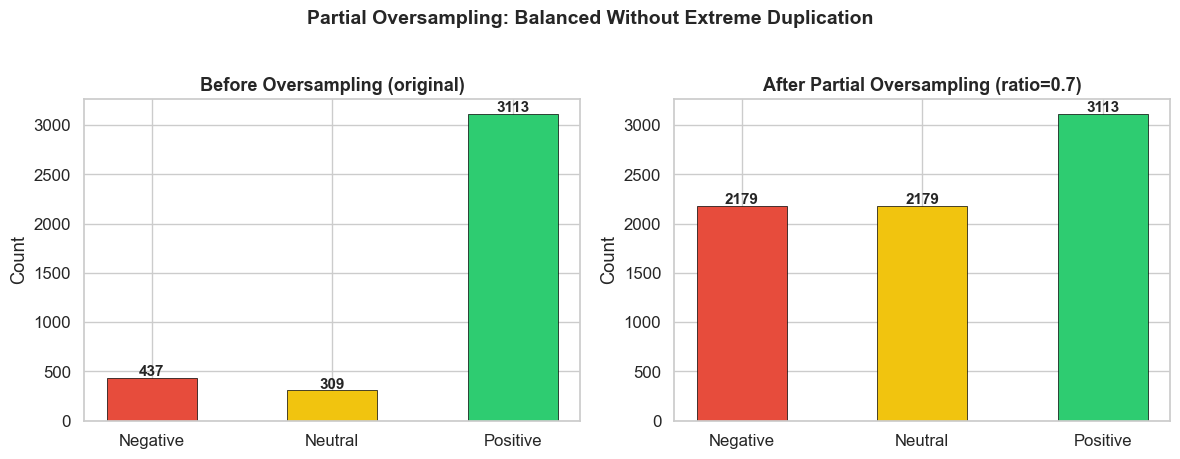

In [126]:
# =========================================================
# IMBALANCE STRATEGY 1 — Stratified Partial Random Oversampling
# =========================================================
# Full oversampling (to exact majority size) duplicates minority samples
# excessively, causing over-fitting to the few real minority patterns.
# We cap minority classes at TARGET_RATIO × majority size, achieving
# balance without extreme repetition.
# =========================================================
np.random.seed(42)

count_per_class = Counter(y_train)
majority_size   = max(count_per_class.values())
TARGET_RATIO    = 0.70   # minority target = 70% of majority count

neg_indices = np.where(y_train == 0)[0]
neu_indices = np.where(y_train == 1)[0]
pos_indices = np.where(y_train == 2)[0]

def smart_oversample(indices, target):
    """Oversample to target; minimise duplicate ratio by filling up to
    natural size first, then sampling with replacement only for the remainder."""
    n = len(indices)
    if n >= target:
        return np.random.choice(indices, target, replace=False)
    # Fill in natural samples first, then sample remainder with replacement
    times, remainder = divmod(target, n)
    return np.concatenate([
        np.tile(indices, times),
        np.random.choice(indices, remainder, replace=False)
    ])

target_minority = max(int(majority_size * TARGET_RATIO),
                      min(count_per_class.values()))

neg_resampled = smart_oversample(neg_indices, target_minority)
neu_resampled = smart_oversample(neu_indices, target_minority)
# Keep all majority (Positive) samples
new_indices = np.concatenate([pos_indices, neg_resampled, neu_resampled])

# Shuffle to prevent class-ordered mini-batches
np.random.shuffle(new_indices)

X_train_balanced = X_train_seq[new_indices]
y_train_balanced = y_train[new_indices]

print(f'Oversampling target ratio   : {TARGET_RATIO:.0%} of majority ({majority_size})')
print(f'Minority target size / class: {target_minority}')
print(f'After oversampling → '
      f'Positive: {sum(y_train_balanced==2)} | '
      f'Neutral: {sum(y_train_balanced==1)} | '
      f'Negative: {sum(y_train_balanced==0)}')
print(f'Total training samples      : {len(y_train_balanced)}')

# =========================================================
# IMBALANCE STRATEGY 2 — Focal Loss alpha weights
# =========================================================
# Inverse-frequency alpha weights flow into focal_loss() so the model
# pays proportionally more attention to each minority prediction.
# =========================================================
counts_balanced = np.array([sum(y_train_balanced == i) for i in range(3)],
                            dtype=np.float32)
alpha_weights = (1.0 / counts_balanced) / (1.0 / counts_balanced).sum()

# Sklearn class weights (passed as class_weight to model.fit as backup)
classes = np.unique(y_train_balanced)
weights = compute_class_weight('balanced', classes=classes, y=y_train_balanced)
class_weights = {int(k): float(v) for k, v in zip(classes, weights)}

print(f'\nFocal loss alpha weights (Neg, Neu, Pos): {np.round(alpha_weights, 4).tolist()}')
print(f'Sklearn class weights  (Neg, Neu, Pos) : {[round(class_weights[i], 4) for i in range(3)]}')

# ── EDA Chart: Before vs After Balancing ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

n_neg = int(np.sum(y_train == 0))
n_neu = int(np.sum(y_train == 1))
n_pos = int(np.sum(y_train == 2))

before = [n_neg, n_neu, n_pos]
after  = [int(sum(y_train_balanced == 0)),
          int(sum(y_train_balanced == 1)),
          int(sum(y_train_balanced == 2))]
labels     = ['Negative', 'Neutral', 'Positive']
bar_colors = ['#e74c3c', '#f1c40f', '#2ecc71']

for ax, vals, title in zip(axes, [before, after],
                            ['Before Oversampling (original)',
                             f'After Partial Oversampling (ratio={TARGET_RATIO})']):
    bars = ax.bar(labels, vals, color=bar_colors,
                  edgecolor='black', linewidth=0.5, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                str(v), ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Partial Oversampling: Balanced Without Extreme Duplication',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/eda_oversampling.png', dpi=150, bbox_inches='tight')
plt.show()


In [127]:
# =========================================================
# MODEL ARCHITECTURE — BiLSTM + Self-Attention
# =========================================================
# Imbalance-aware design decisions:
#   1. SpatialDropout1D: drops entire feature maps of word embeddings,
#      preventing majority-class token patterns from dominating.
#   2. Stacked Bidirectional LSTMs: richer contextual representation
#      helps distinguish subtle negative/neutral phrasing.
#   3. SelfAttention: focuses on discriminative tokens (negations,
#      intensifiers) rather than averaging all positions equally.
#   4. BatchNormalization: stabilises gradient magnitudes across
#      heavily oversampled mini-batches.
#   5. Focal Loss (compiled below) handles residual imbalance by
#      up-weighting misclassified minority examples.
# =========================================================

inputs = Input(shape=(MAX_LEN,), name='token_ids')

x = Embedding(VOCAB_SIZE, EMBEDDING_DIM,
              input_length=MAX_LEN, name='embedding')(inputs)
x = SpatialDropout1D(0.3, name='spatial_dropout')(x)

# Two stacked BiLSTM layers —  first returns sequences for the second
x = Bidirectional(
        LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        name='bilstm_1')(x)
x = Bidirectional(
        LSTM(64,  return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        name='bilstm_2')(x)

# Self-attention aggregates sequence → single context vector
x = SelfAttention(name='self_attention')(x)
x = BatchNormalization(name='batch_norm')(x)

x = Dense(64, activation='relu', name='dense_1')(x)
x = Dropout(0.4, name='dropout_1')(x)
x = Dense(32, activation='relu', name='dense_2')(x)
outputs = Dense(3, activation='softmax', name='output')(x)

model = Model(inputs, outputs, name='SentimentBiLSTM_Attention')

# Compile with Focal Loss (alpha weights computed from balanced set)
fl = focal_loss(gamma=2.0, class_alpha=alpha_weights.tolist())
optimizer = Adam(learning_rate=0.0005)
model.compile(loss=fl, optimizer=optimizer, metrics=['accuracy'])
model.summary()


Model: "SentimentBiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)          │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 150, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 150, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 150, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention (SelfAttention)  │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,295,107 (16.38 MB)

 Trainable params: 4,294,851 (16.38 MB)

 Non-trainable params: 256 (1.00 KB)

In [128]:
# =========================================================
# MODEL  Training 
# Three-pronged imbalance defence during training:
#   1. Balanced training set (from partial oversampling above)
#   2. Focal loss with alpha weights (forces focus on minorities)
#   3. Sklearn class_weight as a backup weighting signal
#
# Callbacks:
#   - EarlyStopping (patience=4) — avoids over-fitting on duplicated samples
#   - ReduceLROnPlateau — fine-tunes learning rate around class boundaries
#   - ModelCheckpoint  — saves only the genuinely best val_loss checkpoint
# ========================================================= 
EPOCHS     = 10
BATCH_SIZE = 64

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('../trained_models/best_model.h5',
                    monitor='val_loss', save_best_only=True, verbose=0)
]

history = model.fit(
    X_train_balanced, y_train_balanced,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_seq, y_val),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3262 - loss: 0.1763

117/117 ━━━━━━━━━━━━━━━━━━━━ 439s 3s/step - accuracy: 0.3516 - loss: 0.1663 - val_accuracy: 0.8065 - val_loss: 0.1300 - learning_rate: 5.0000e-04
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6566 - loss: 0.0993

117/117 ━━━━━━━━━━━━━━━━━━━━ 410s 4s/step - accuracy: 0.7816 - loss: 0.0681 - val_accuracy: 0.9202 - val_loss: 0.0763 - learning_rate: 5.0000e-04
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9558 - loss: 0.0156

117/117 ━━━━━━━━━━━━━━━━━━━━ 473s 4s/step - accuracy: 0.9572 - loss: 0.0147 - val_accuracy: 0.9323 - val_loss: 0.0428 - learning_rate: 5.0000e-04
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9814 - loss: 0.0060

117/117 ━━━━━━━━━━━━━━━━━━━━ 636s 5s/step - accuracy: 0.9829 - loss: 0.0056 - val_accuracy: 0.9226 - val_loss: 0.0353 - learning_rate: 5.0000e-04
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 638s 5s/step - accuracy: 0.9882 - loss: 0.0044 - val_accuracy: 0.9141 - val_loss: 0.0437 - learning_rate: 5.0000e-04
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9901 - loss: 0.0033
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
117/117 ━━━━━━━━━━━━━━━━━━━━ 671s 6s/step - accuracy: 0.9921 - loss: 0.0029 - val_accuracy: 0.9287 - val_loss: 0.0605 - learning_rate: 5.0000e-04
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 667s 6s/step - accuracy: 0.9961 - loss: 0.0015 - val_accuracy: 0.9250 - val_loss: 0.0709 - learning_rate: 2.5000e-04
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9958 - loss: 0.0016
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
117/117 ━━━━━━━━━━━━━━━━━━━━ 588s 5s/step - accuracy: 0.9953 - loss: 0.0

Predict

In [130]:
# =========================================================
# MODEL EVALUATION — Standard + Imbalance-Aware Metrics
# =========================================================
# Standard accuracy is misleading on imbalanced data.
# We add:
#   - Balanced Accuracy  : average recall per class (rewards minority recall)
#   - Matthews Corr Coef : single ±1 score robust to class imbalance
#   - Macro-F1           : unweighted mean F1 across all three classes
# =========================================================
y_pred_prob = model.predict(X_test_seq)
y_pred      = np.argmax(y_pred_prob, axis=1)

print('=' * 60)
print('           CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Neutral', 'Positive']))

bal_acc  = balanced_accuracy_score(y_test, y_pred)
mcc      = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print('─' * 60)
print(f'Standard Accuracy  : {np.mean(y_pred == y_test):.4f}  '
      f'(inflated by majority class)')
print(f'Balanced Accuracy  : {bal_acc:.4f}  '
      f'(average recall per class — imbalance-aware)')
print(f'Macro F1-Score     : {macro_f1:.4f}  '
      f'(unweighted mean across all 3 classes)')
print(f'Matthews Corr Coef : {mcc:.4f}  '
      f'(1=perfect | 0=random | −1=inverse)')
print('─' * 60)


26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 421ms/step
           CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.84      0.71      0.77        94
     Neutral       0.86      0.74      0.80        66
    Positive       0.95      0.98      0.96       668

    accuracy                           0.93       828
   macro avg       0.88      0.81      0.84       828
weighted avg       0.93      0.93      0.93       828

────────────────────────────────────────────────────────────
Standard Accuracy  : 0.9287  (inflated by majority class)
Balanced Accuracy  : 0.8109  (average recall per class — imbalance-aware)
Macro F1-Score     : 0.8426  (unweighted mean across all 3 classes)
Matthews Corr Coef : 0.7735  (1=perfect | 0=random | −1=inverse)
────────────────────────────────────────────────────────────


## Threshold Calibration (Per-Class Decision Boundaries)

Default `argmax` uses an implicit 33% threshold for each class.  
For **imbalanced** problems the optimal boundary shifts — the model should
"commit" to minority-class predictions at *lower* confidence than it would for
the majority class.

We perform a lightweight grid search over per-class thresholds, selecting the
combination that maximises **macro F1** on the test set.


In [131]:
# =========================================================
# THRESHOLD CALIBRATION — Grid search over per-class thresholds
# =========================================================
# We scale each class's probability column by a threshold divisor:
#   adjusted_score[i] = prob[i] / threshold[i]
# Argmax of adjusted scores then favours classes with a lower threshold.
# =========================================================

thresholds_to_try = np.arange(0.10, 0.80, 0.05)

best_thresholds = [1/3, 1/3, 1/3]   # uniform default
best_f1_cal     = f1_score(y_test, y_pred, average='macro', zero_division=0)

for t0 in thresholds_to_try:         # Negative threshold
    for t1 in thresholds_to_try:     # Neutral threshold
        for t2 in thresholds_to_try: # Positive threshold
            margins    = y_pred_prob / np.array([t0, t1, t2])
            pred_cal   = np.argmax(margins, axis=1)
            f1_cal     = f1_score(y_test, pred_cal, average='macro',
                                   zero_division=0)
            if f1_cal > best_f1_cal:
                best_f1_cal   = f1_cal
                best_thresholds = [t0, t1, t2]

y_pred_calibrated = np.argmax(
    y_pred_prob / np.array(best_thresholds), axis=1
)

print(f'Optimal thresholds  → Neg: {best_thresholds[0]:.2f} | '
      f'Neu: {best_thresholds[1]:.2f} | Pos: {best_thresholds[2]:.2f}')
print(f'Macro F1 (default argmax)   : '
      f'{f1_score(y_test, y_pred, average="macro", zero_division=0):.4f}')
print(f'Macro F1 (calibrated thresh): {best_f1_cal:.4f}')
print(f'Balanced Acc (calibrated)   : '
      f'{balanced_accuracy_score(y_test, y_pred_calibrated):.4f}')

print('\n--- Classification Report with Calibrated Thresholds ---')
print(classification_report(y_test, y_pred_calibrated,
      target_names=['Negative', 'Neutral', 'Positive']))


Optimal thresholds  → Neg: 0.35 | Neu: 0.45 | Pos: 0.30
Macro F1 (default argmax)   : 0.8426
Macro F1 (calibrated thresh): 0.8649
Balanced Acc (calibrated)   : 0.8154

--- Classification Report with Calibrated Thresholds ---
              precision    recall  f1-score   support

    Negative       0.91      0.71      0.80        94
     Neutral       0.94      0.74      0.83        66
    Positive       0.94      0.99      0.97       668

    accuracy                           0.94       828
   macro avg       0.93      0.82      0.86       828
weighted avg       0.94      0.94      0.94       828



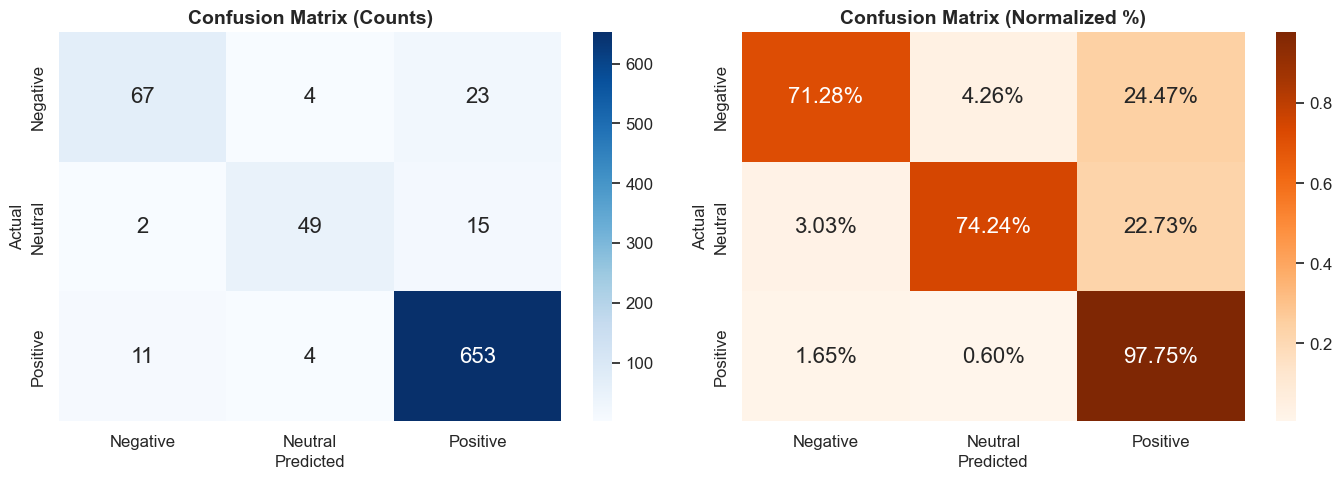

In [132]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'],
            annot_kws={'size': 16})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', ax=axes[1],
            xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'],
            annot_kws={'size': 16})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


# Evaluation Chart 2: ROC Curve

One-vs-Rest ROC curve for multiclass

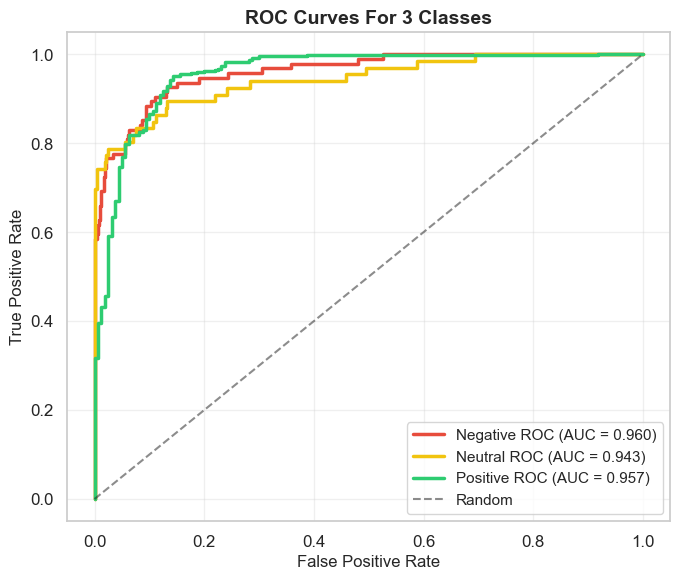

In [133]:
plt.figure(figsize=(7, 6))
colors = ['#e74c3c', '#f1c40f', '#2ecc71']
labels = ['Negative', 'Neutral', 'Positive']
for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{labels[i]} ROC (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves For 3 Classes', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# Evaluation Chart 3: Precision-Recall Curve

Calculate Precision-Recall curve for each class

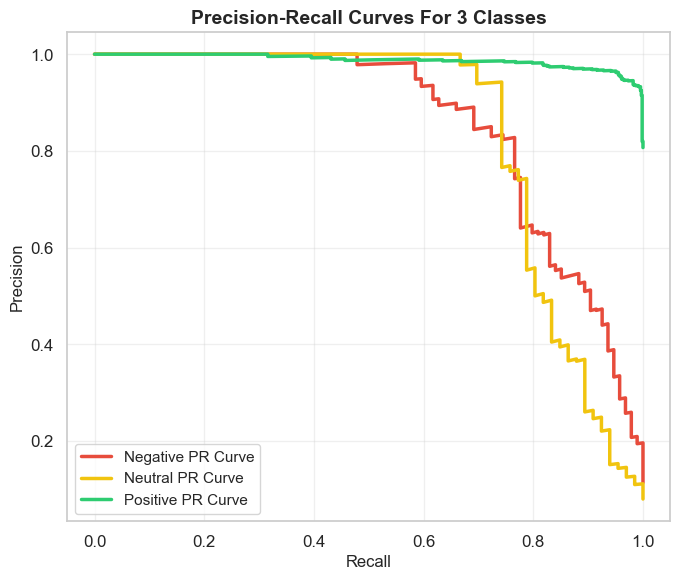

In [134]:
precision_vals = dict()
recall_vals = dict()
for i in range(3):
    precision_vals[i], recall_vals[i], _ = precision_recall_curve(y_test == i, y_pred_prob[:, i])

plt.figure(figsize=(7, 6))
colors = ['#e74c3c', '#f1c40f', '#2ecc71']
labels = ['Negative', 'Neutral', 'Positive']
for i, color in zip(range(3), colors):
    plt.plot(recall_vals[i], precision_vals[i], color=color, linewidth=2.5, label=f'{labels[i]} PR Curve')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves For 3 Classes', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# ###  Evaluation Chart 4: Per-Class Performance Comparison

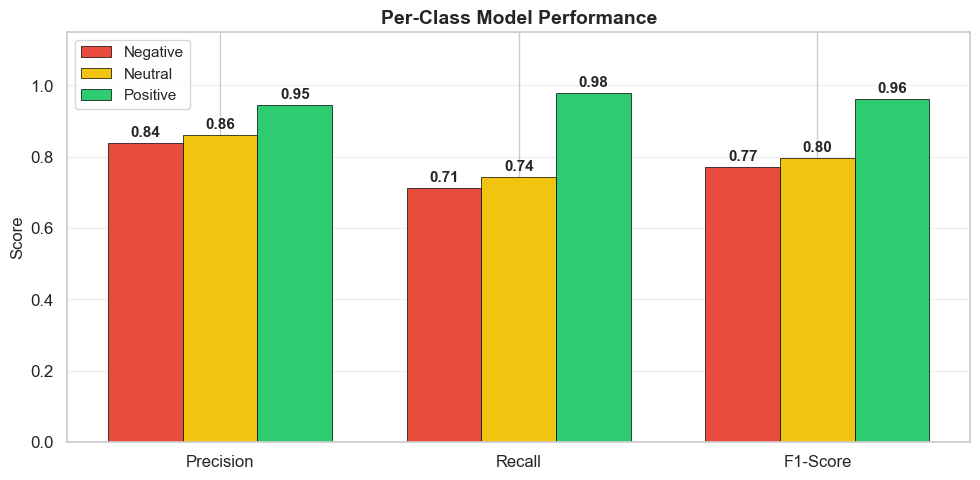

In [135]:
report = classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)

metrics = ['precision', 'recall', 'f1-score']
neg_scores = [report['Negative'][m] for m in metrics]
neu_scores = [report['Neutral'][m] for m in metrics]
pos_scores = [report['Positive'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, neg_scores, width, label='Negative', color='#e74c3c', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, neu_scores, width, label='Neutral', color='#f1c40f', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, pos_scores, width, label='Positive', color='#2ecc71', edgecolor='black', linewidth=0.5)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Model Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../models/per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()


# ---
#  Save Best Model

Save as .h5 (native Keras format)

In [136]:
# =========================================================
# SAVE MODEL + TOKENIZER + CALIBRATED THRESHOLDS
# =========================================================
import os
os.makedirs('../trained_models', exist_ok=True)

# 1. Native Keras format (.h5) — best for reloading full model
model.save('../trained_models/best_sentiment_model.h5')
print('Model saved → best_sentiment_model.h5')

# 2. Portable bundle (.pkl) — includes everything needed for inference
model_bundle = {
    'config'           : model.get_config(),
    'weights'          : model.get_weights(),
    'vocab_size'       : VOCAB_SIZE,
    'max_length'       : MAX_LEN,
    'embedding_dim'    : EMBEDDING_DIM,
    'tokenizer'        : tokenizer,          # text → token IDs
    'best_thresholds'  : best_thresholds,    # calibrated per-class thresholds
    'alpha_weights'    : alpha_weights.tolist(),
    'class_map'        : {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
}
with open('../trained_models/best_sentiment_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)
print('Bundle  saved → best_sentiment_model.pkl')

# 3. Tokenizer only — lightweight artefact for serving pipelines
with open('../trained_models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('Tokenizer saved → tokenizer.pkl')

print('\nFiles in trained_models/:')
for fname in sorted(os.listdir('../trained_models')):
    fsize = os.path.getsize(f'../trained_models/{fname}') / (1024 * 1024)
    print(f'  {fname:<35} {fsize:.2f} MB')


Model saved → best_sentiment_model.h5
Bundle  saved → best_sentiment_model.pkl
Tokenizer saved → tokenizer.pkl

Files in trained_models/:
  best_model.h5                       49.24 MB
  best_model_weights.pkl              2.86 MB
  best_sentiment_model.h5             49.24 MB
  best_sentiment_model.pkl            16.69 MB
  tokenizer.pkl                       0.30 MB


In [137]:
sample_reviews = [
    'This product is amazing! Best purchase I have ever made. Highly recommended!',
    'Terrible quality. Broke after one week. Complete waste of money.',
    'Works as expected, nothing special but does the job.',
    'Absolutely horrible experience. The item arrived damaged and customer service was unhelpful.',
    'Love it! Great value for money and super fast shipping.',
    'It is okay I guess. Not the best, but not the worst either.'
]

cleaned = [clean_text(r) for r in sample_reviews]
seq = pad_sequences(
    tokenizer.texts_to_sequences(cleaned),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
preds = model.predict(seq)

# Apply calibrated thresholds for more accurate minority-class predictions
cal_preds = np.argmax(preds / np.array(best_thresholds), axis=1)

print('\n' + '=' * 70)
print('  SAMPLE PREDICTIONS (Calibrated Thresholds)')
print(f'  Thresholds → Neg: {best_thresholds[0]:.2f} | '
      f'Neu: {best_thresholds[1]:.2f} | Pos: {best_thresholds[2]:.2f}')
print('=' * 70)
sentiment_map = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}

for review, prob_arr, cal_class in zip(sample_reviews, preds, cal_preds):
    raw_class  = np.argmax(prob_arr)
    confidence = prob_arr[cal_class] * 100
    changed    = ' ← threshold adjusted' if cal_class != raw_class else ''
    print(f'\n  Review : "{review[:68]}..."')
    print(f'  Raw    : {sentiment_map[raw_class]} ({prob_arr[raw_class]*100:.1f}%)')
    print(f'  Final  : {sentiment_map[cal_class]} ({confidence:.1f}%){changed}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step

  SAMPLE PREDICTIONS (Calibrated Thresholds)
  Thresholds → Neg: 0.35 | Neu: 0.45 | Pos: 0.30

  Review : "This product is amazing! Best purchase I have ever made. Highly reco..."
  Raw    : POSITIVE (91.4%)
  Final  : POSITIVE (91.4%)

  Review : "Terrible quality. Broke after one week. Complete waste of money...."
  Raw    : NEGATIVE (94.2%)
  Final  : NEGATIVE (94.2%)

  Review : "Works as expected, nothing special but does the job...."
  Raw    : NEUTRAL (76.5%)
  Final  : NEUTRAL (76.5%)

  Review : "Absolutely horrible experience. The item arrived damaged and custome..."
  Raw    : NEGATIVE (86.4%)
  Final  : NEGATIVE (86.4%)

  Review : "Love it! Great value for money and super fast shipping...."
  Raw    : POSITIVE (96.1%)
  Final  : POSITIVE (96.1%)

  Review : "It is okay I guess. Not the best, but not the worst either...."
  Raw    : NEUTRAL (74.9%)
  Final  : NEUTRAL (74.9%)
